# Project 11 — Multimodal Fake News Detection
## Data Exploration, Cleaning & Quality Checks

**Dataset:** FakeNewsNet (CSV minimalistic version + downloaded `news content.json` files)  
### Notebook Structure
1. Setup & paths
2. Load the four CSVs
3. Basic shape & label distribution
4. Missing-value audit
5. Text column exploration (title & article body)
6. Image URL exploration
7. `news content.json` exploration (if downloaded)
8. Tweet-ID column exploration
9. Data cleaning & deduplication
10. Balanced subset construction
11. Summary & next-step checklist

## MS1 Grading Alignment

This notebook supports the **Methodology** and **Preliminary Experiments and Results** sections of the IEEE-style midterm report.

**What this notebook demonstrates:**
- Dataset source and structure: FakeNewsNet `gossipcop` and `politifact` subsets.
- Data quality audit: missing values, duplicates, URL/domain quality, and tweet metadata availability.
- Text exploration: title length, punctuation, and title anomalies.
- Source-bias analysis: label distribution by source and top news domains.
- Train/validation/test construction: balanced and stratified splits for the initial milestone.

**Connection to the project:** the final project is about **image--text inconsistency**. The CSV labels are `fake` and `real`; for MS1, these labels are used as a practical proxy while the pipeline is prepared to combine article titles/text with downloaded news images in the next notebooks.


## 1 · Setup & Paths

In [2]:
# ── standard installs (run once) ──────────────────────────────────────────────
# !pip install pandas matplotlib seaborn wordcloud requests tqdm Pillow --quiet

import os, json, re, warnings
from pathlib import Path
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.max_columns', 20)

# ── colour palette ─────────────────────────────────────────────────────────────
FAKE_CLR  = '#E53935'
REAL_CLR  = '#1E88E5'
PALETTE   = {'fake': FAKE_CLR, 'real': REAL_CLR}

# ── ROOT PATHS  ── adjust these to your local clone of FakeNewsNet ─────────────
# CSV files are in the 'dataset/' folder of the repo
CSV_DIR   = Path('dataset')          # path/to/FakeNewsNet/dataset

# Full downloaded FakeNewsNet article-content dataset.
# This is different from image_manifests/ and different from the four CSV files in dataset/.
# Expected structure: DATA_DIR / source / label / article_id / 'news content.json'
DATA_DIR = Path('fakenewsnet_full_dataset')
FULL_DATA_AVAILABLE = any((DATA_DIR / source / label).exists()
                          for source in ['politifact', 'gossipcop']
                          for label in ['fake', 'real'])

print('CSV_DIR  exists:', CSV_DIR.exists())
print('DATA_DIR exists:', DATA_DIR.exists())
print('Full content JSON structure detected:', FULL_DATA_AVAILABLE)

# ?? ROOT PATHS: this project's actual local layout ???????????????????????????
CSV_DIR = Path('dataset')
DATA_SPLIT_DIR = Path('data_splits')
IMAGE_DIR = Path('images')
MANIFEST_DIR = Path('image_manifests')
FINAL_ARTIFACT_DIR = Path('final_artifacts')
FINAL_ARTIFACT_DIR.mkdir(exist_ok=True)

# Optional full FakeNewsNet article-body dataset. This is NOT the images folder
# and NOT image_manifests/. Keep it optional because the current project has
# CSV metadata plus downloaded images/manifests.
DATA_DIR = Path('fakenewsnet_full_dataset')
FULL_DATA_AVAILABLE = any((DATA_DIR / source / label).exists()
                          for source in ['politifact', 'gossipcop']
                          for label in ['fake', 'real'])
IMAGE_MANIFESTS_AVAILABLE = all((MANIFEST_DIR / f'{split}_image_manifest.csv').exists()
                                for split in ['train', 'val', 'test'])
MULTIMODAL_SPLITS_AVAILABLE = all((DATA_SPLIT_DIR / f'{split}_multimodal.csv').exists()
                                  for split in ['train', 'val', 'test'])

print('CSV_DIR exists:', CSV_DIR.exists())
print('DATA_SPLIT_DIR exists:', DATA_SPLIT_DIR.exists())
print('IMAGE_DIR exists:', IMAGE_DIR.exists())
print('MANIFEST_DIR exists:', MANIFEST_DIR.exists())
print('Full article-content JSON structure detected:', FULL_DATA_AVAILABLE)
print('Image manifests detected:', IMAGE_MANIFESTS_AVAILABLE)
print('Multimodal split CSVs detected:', MULTIMODAL_SPLITS_AVAILABLE)

CSV_DIR  exists: True
DATA_DIR exists: False
Full content JSON structure detected: False
CSV_DIR exists: True
DATA_SPLIT_DIR exists: True
IMAGE_DIR exists: True
MANIFEST_DIR exists: True
Full article-content JSON structure detected: False
Image manifests detected: True
Multimodal split CSVs detected: True


## 2 · Load the Four CSVs

In [3]:
def load_csv(source: str, label: str) -> pd.DataFrame:
    """Load one of the four CSVs and attach source/label columns."""
    path = CSV_DIR / f'{source}_{label}.csv'
    df   = pd.read_csv(path)
    df['source'] = source
    df['label']  = label
    return df

pf_fake = load_csv('politifact', 'fake')
pf_real = load_csv('politifact', 'real')
gc_fake = load_csv('gossipcop',  'fake')
gc_real = load_csv('gossipcop',  'real')

raw = pd.concat([pf_fake, pf_real, gc_fake, gc_real], ignore_index=True)

print(f'Total rows: {len(raw):,}')
raw.head(3)

Total rows: 23,196


,id,news_url,title,tweet_ids,source,label
0,politifact15014,speedtalk.com/forum/viewtopic.php?t=51650,BREAKING: First NFL Team Declares Bankruptcy Over Kneeling Thugs,937349434668498944\t937379378006282240\t937380068590055425\t937384406511005696\t937387493451862016\t9374007660248965...,politifact,fake
1,politifact15156,politics2020.info/index.php/2018/03/13/court-orders-obama-to-pay-400-million-in-restitution/,Court Orders Obama To Pay $400 Million In Restitution,972666281441878016\t972678396575559680\t972827819993595904\t972828014269448192\t972828016647663616\t9728285718310625...,politifact,fake
2,politifact14745,www.nscdscamps.org/blog/category/parenting/467344/update-second-roy-moore-accuser-works-for-michelle-obama-right-now...,UPDATE: Second Roy Moore Accuser Works For Michelle Obama Right NOW -,929405740732870656\t929439450400264192\t929439484806037506\t929484662145208320\t929498602539450368\t9295037309611253...,politifact,fake


## 3 · Basic Shape & Label Distribution

In [4]:
print('Columns:', raw.columns.tolist())
print('\nShape per (source, label):')
print(raw.groupby(['source', 'label']).size().unstack(fill_value=0))

Columns: ['id', 'news_url', 'title', 'tweet_ids', 'source', 'label']

Shape per (source, label):
label       fake   real
source                 
gossipcop   5323  16817
politifact   432    624


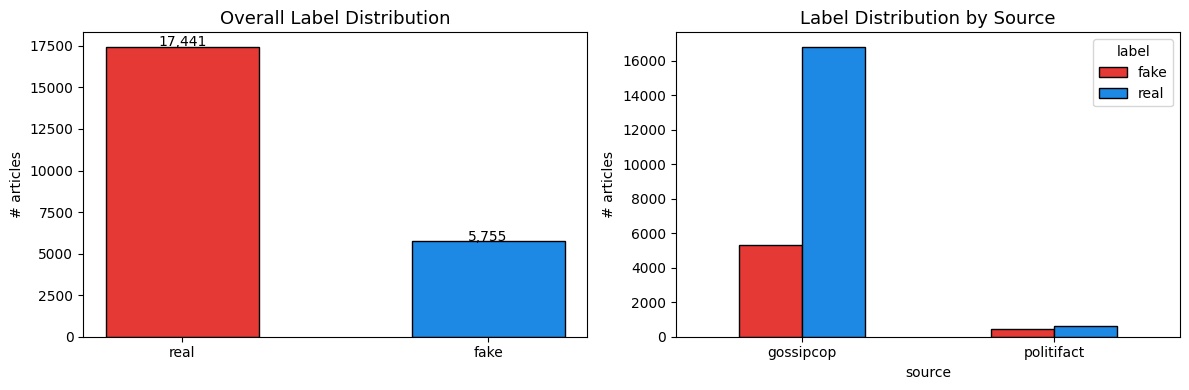


Class imbalance ratio (fake/real):
source
gossipcop     0.316525
politifact    0.692308
Name: ratio, dtype: float64


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Overall label split
counts = raw['label'].value_counts()
axes[0].bar(counts.index, counts.values,
            color=[FAKE_CLR, REAL_CLR], edgecolor='black', width=0.5)
axes[0].set_title('Overall Label Distribution', fontsize=13)
axes[0].set_ylabel('# articles')
for bar, v in zip(axes[0].patches, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f'{v:,}', ha='center', fontsize=10)

# Per-source label split
grp = raw.groupby(['source', 'label']).size().unstack(fill_value=0)
grp.plot(kind='bar', ax=axes[1], color=[FAKE_CLR, REAL_CLR],
         edgecolor='black', rot=0)
axes[1].set_title('Label Distribution by Source', fontsize=13)
axes[1].set_ylabel('# articles')
axes[1].legend(title='label')

plt.tight_layout()
plt.savefig('plot_01_label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nClass imbalance ratio (fake/real):')
print((raw.groupby(['source', 'label']).size().unstack()
          .assign(ratio=lambda d: d['fake']/d['real']))['ratio'])

## 4 · Missing-Value Audit

In [6]:
def missing_report(df: pd.DataFrame, name: str = ''):
    miss = df.isnull().sum()
    pct  = (miss / len(df) * 100).round(2)
    report = pd.DataFrame({'missing_count': miss, 'missing_%': pct})
    report = report[report['missing_count'] > 0].sort_values('missing_%', ascending=False)
    print(f'--- Missing values: {name} ---')
    print(report if len(report) else '  No missing values.')
    return report

_ = missing_report(raw, 'all data')
print()
for src in ['politifact', 'gossipcop']:
    _ = missing_report(raw[raw['source'] == src], src)

--- Missing values: all data ---
           missing_count  missing_%
tweet_ids           1501       6.47
news_url             330       1.42

--- Missing values: politifact ---
           missing_count  missing_%
tweet_ids            255      24.15
news_url              61       5.78
--- Missing values: gossipcop ---
           missing_count  missing_%
tweet_ids           1246       5.63
news_url             269       1.21


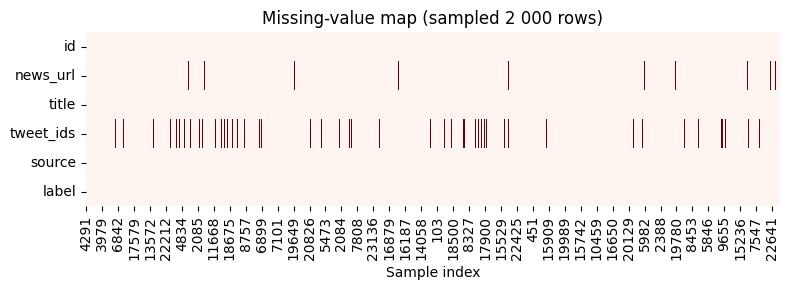

In [7]:
# Visualise missingness as a heatmap
fig, ax = plt.subplots(figsize=(8, 3))
miss_matrix = raw.isnull().astype(int)
# sample at most 2000 rows for visibility
sample_idx  = miss_matrix.sample(min(2000, len(miss_matrix)), random_state=42).index
sns.heatmap(miss_matrix.loc[sample_idx].T, cmap='Reds', cbar=False,
            yticklabels=raw.columns, ax=ax)
ax.set_title('Missing-value map (sampled 2 000 rows)', fontsize=12)
ax.set_xlabel('Sample index')
plt.tight_layout()
plt.savefig('plot_02_missing_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 5 · Text Column Exploration (title)

In [8]:
# ── 5.1 Basic string stats ─────────────────────────────────────────────────────
raw['title_len_chars'] = raw['title'].fillna('').str.len()
raw['title_len_words'] = raw['title'].fillna('').str.split().str.len()

print('Title length (characters):')
print(raw.groupby('label')['title_len_chars'].describe().round(1))
print('\nTitle length (words):')
print(raw.groupby('label')['title_len_words'].describe().round(1))

Title length (characters):
         count  mean   std   min   25%   50%   75%    max
label                                                    
fake    5755.0  68.8  23.8  10.0  54.0  69.0  84.0  200.0
real   17441.0  68.1  23.1  10.0  55.0  68.0  83.0  340.0

Title length (words):
         count  mean  std  min  25%   50%   75%   max
label                                                
fake    5755.0  11.1  4.0  1.0  9.0  11.0  14.0  38.0
real   17441.0  11.2  4.0  1.0  9.0  11.0  14.0  53.0


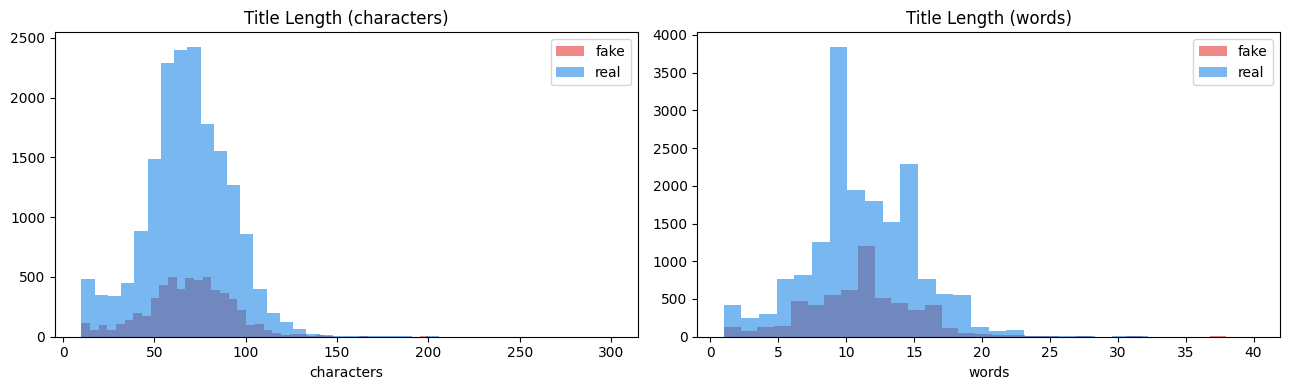

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for label, grp in raw.groupby('label'):
    axes[0].hist(grp['title_len_chars'].clip(0, 300), bins=40,
                 alpha=0.6, label=label, color=PALETTE[label])
    axes[1].hist(grp['title_len_words'].clip(0, 40), bins=30,
                 alpha=0.6, label=label, color=PALETTE[label])

axes[0].set_title('Title Length (characters)', fontsize=12)
axes[0].set_xlabel('characters'); axes[0].legend()
axes[1].set_title('Title Length (words)',      fontsize=12)
axes[1].set_xlabel('words');      axes[1].legend()

plt.tight_layout()
plt.savefig('plot_03_title_length.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# ── 5.2 Character-level anomalies ─────────────────────────────────────────────
raw['title_has_null']  = raw['title'].isnull()
raw['title_is_empty']  = raw['title'].fillna('').str.strip().eq('')
raw['title_is_url']    = raw['title'].fillna('').str.startswith('http')
raw['title_all_caps']  = raw['title'].fillna('').apply(
    lambda t: t.isupper() and len(t.split()) > 3)

flags = ['title_has_null', 'title_is_empty', 'title_is_url', 'title_all_caps']
print('Title anomaly counts:')
print(raw[flags].sum().to_string())

Title anomaly counts:
title_has_null     0
title_is_empty     0
title_is_url       1
title_all_caps    49


In [11]:
# ── 5.3 Sample titles per class ───────────────────────────────────────────────
print('=== Sample FAKE titles ===')
print(raw[raw['label']=='fake']['title'].dropna().sample(5, random_state=1).tolist())
print('\n=== Sample REAL titles ===')
print(raw[raw['label']=='real']['title'].dropna().sample(5, random_state=1).tolist())

=== Sample FAKE titles ===
['Why Katie Holmes and Jamie Foxx Never Leave a Dinner Date Together', 'INTO: A Digital Magazine for The Modern Queer World', 'Apology To Sarah Ferguson', 'Celebrities Respond as President Trump Backs Out of Paris Accord – Variety', 'Angelina Jolie ‘Misses’ Connection With Brad Pitt — It Used To Be ‘Them Against The World’']

=== Sample REAL titles ===
['‘Teen Mom OG’ Star Maci Bookout Looks To Have A Baby Bump In New Instagram Photo', 'Jenna Bush Hager', "Exclusive: Go behind the scenes of 'A Wrinkle in Time' with Oprah Winfrey", 'TV Scoop Awards 2017: Vote for the Best Fandom and Best Cast on Social Media Now', "What is Tarek El Moussa's Net Worth?"]


In [12]:
# ── 5.4 Special-character & punctuation density ────────────────────────────────
def punct_density(text: str) -> float:
    if not isinstance(text, str) or len(text) == 0:
        return 0.0
    return sum(1 for c in text if not c.isalnum() and c != ' ') / len(text)

def exclamation_count(text: str) -> int:
    return text.count('!') if isinstance(text, str) else 0

def question_count(text: str) -> int:
    return text.count('?') if isinstance(text, str) else 0

raw['title_punct_density']   = raw['title'].apply(punct_density)
raw['title_exclaim_count']   = raw['title'].apply(exclamation_count)
raw['title_question_count']  = raw['title'].apply(question_count)

print('Punctuation density by label:')
print(raw.groupby('label')['title_punct_density'].describe().round(4))
print('\nExclamation marks (total) by label:')
print(raw.groupby('label')['title_exclaim_count'].sum())

Punctuation density by label:
         count    mean     std  min  25%     50%     75%     max
label                                                           
fake    5755.0  0.0266  0.0239  0.0  0.0  0.0230  0.0408  0.2143
real   17441.0  0.0265  0.0249  0.0  0.0  0.0222  0.0405  0.2424

Exclamation marks (total) by label:
label
fake    409
real    977
Name: title_exclaim_count, dtype: int64


## 6 · URL Column Exploration

In [13]:
# ── 6.1 URL presence & domain extraction ──────────────────────────────────────
raw['url_missing'] = raw['news_url'].isnull()

def extract_domain(url):
    try:
        if not isinstance(url, str) or len(str(url).strip()) == 0:
            return 'MISSING'
        url = str(url).strip().lower()
        # First try to match http/https
        m = re.search(r'https?://(?:www\.)?([^/?\#]+)', url)
        if m:
            return m.group(1)
        # If no scheme, try to extract domain directly
        m = re.search(r'^(?:www\.)?([^/?\#]+)', url)
        return m.group(1) if m else 'UNKNOWN'
    except Exception as e:
        return 'ERROR'

raw['domain'] = raw['news_url'].apply(extract_domain)

print('Top 15 domains (fake):')
print(raw[raw['label']=='fake']['domain'].value_counts().head(15))
print('\nTop 15 domains (real):')
print(raw[raw['label']=='real']['domain'].value_counts().head(15))

Top 15 domains (fake):
domain
hollywoodlife.com    460
MISSING              260
people.com           216
dailymail.co.uk      194
radaronline.com      174
eonline.com          154
usmagazine.com       147
imdb.com             145
newidea.com.au       137
en.wikipedia.org     123
inquisitr.com        107
etonline.com          81
intouchweekly.com     75
msn.com               74
web.archive.org       69
Name: count, dtype: int64

Top 15 domains (real):
domain
people.com               1570
dailymail.co.uk           770
en.wikipedia.org          618
etonline.com              585
usmagazine.com            562
longroom.com              562
usatoday.com              300
hollywoodreporter.com     298
variety.com               259
ew.com                    214
today.com                 180
billboard.com             164
thewrap.com               162
time.com                  157
elle.com                  154
Name: count, dtype: int64


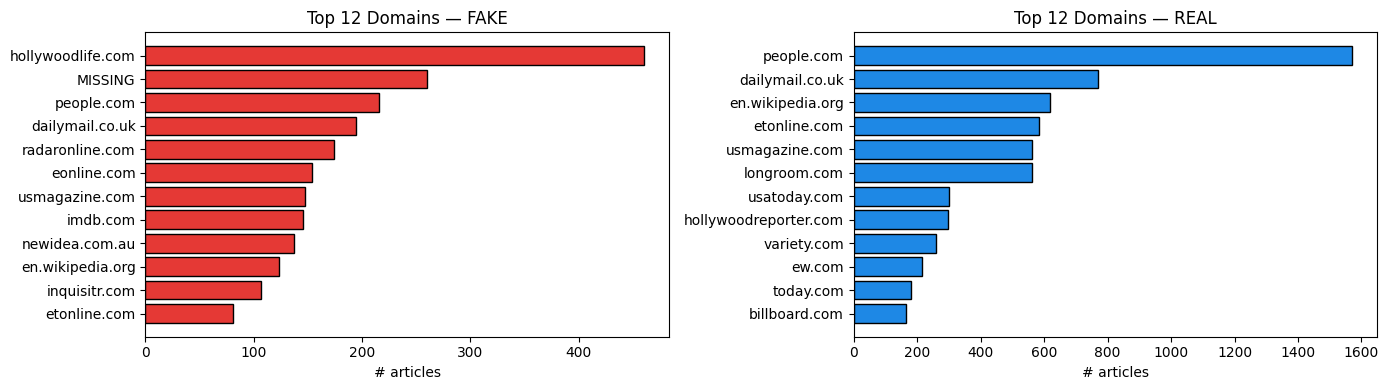

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, label in zip(axes, ['fake', 'real']):
    top = raw[raw['label']==label]['domain'].value_counts().head(12)
    ax.barh(top.index[::-1], top.values[::-1],
            color=PALETTE[label], edgecolor='black')
    ax.set_title(f'Top 12 Domains — {label.upper()}', fontsize=12)
    ax.set_xlabel('# articles')

plt.tight_layout()
plt.savefig('plot_04_domains.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# ── 6.2 URL length ────────────────────────────────────────────────────────────
raw['url_len'] = raw['news_url'].fillna('').str.len()
print('URL length statistics by label:')
print(raw.groupby('label')['url_len'].describe().round(1))

URL length statistics by label:
         count  mean   std  min   25%   50%    75%    max
label                                                    
fake    5755.0  83.7  33.7  0.0  67.0  86.0  103.0  258.0
real   17441.0  96.2  28.4  0.0  77.0  97.0  114.0  331.0


## 7 · `news content.json` Exploration (article body + images)

In [16]:
# 7.1 Load all news content JSON files
# This optional section requires the full FakeNewsNet article-content directory,
# not just the four CSV metadata files and not image_manifests/.

def load_news_content(data_dir: Path) -> pd.DataFrame:
    records = []
    for source in ['politifact', 'gossipcop']:
        for label in ['fake', 'real']:
            folder = data_dir / source / label
            if not folder.exists():
                continue
            for article_dir in folder.iterdir():
                json_path = article_dir / 'news content.json'
                if not json_path.exists():
                    continue
                with open(json_path, 'r', encoding='utf-8', errors='replace') as f:
                    try:
                        content = json.load(f)
                    except json.JSONDecodeError:
                        content = {}
                records.append({
                    'id'          : article_dir.name,
                    'source'      : source,
                    'label'       : label,
                    'text'        : content.get('text', None),
                    'images'      : content.get('images', []),
                    'publish_date': content.get('publish date', None),
                    'top_img'     : content.get('top_img', None),
                    'authors'     : content.get('authors', []),
                    'movies'      : content.get('movies', []),
                    'keywords'    : content.get('keywords', []),
                })
    return pd.DataFrame(records)

content_columns = ['id','source','label','text','images','publish_date','top_img','authors','movies','keywords']

if FULL_DATA_AVAILABLE:
    content_df = load_news_content(DATA_DIR)
    if content_df.empty:
        print(f'No news content JSON files found under {DATA_DIR}. Continuing with CSV-only EDA.')
        content_df = pd.DataFrame(columns=content_columns)
    else:
        print(f'Loaded {len(content_df):,} news content JSON files')
        print(content_df.head(2))
else:
    print('Full article-content JSON dataset not found. Continuing with CSV-only EDA.')
    print("Expected optional layout: DATA_DIR/source/label/article_id/'news content.json'")
    content_df = pd.DataFrame(columns=content_columns)


Full article-content JSON dataset not found. Continuing with CSV-only EDA.
Expected optional layout: DATA_DIR/source/label/article_id/'news content.json'


In [17]:
# ── 7.2 Article body text stats ───────────────────────────────────────────────
if not content_df.empty:
    content_df['text_len_words'] = content_df['text'].fillna('').str.split().str.len()
    content_df['text_len_chars'] = content_df['text'].fillna('').str.len()
    content_df['text_missing']   = content_df['text'].isnull() | content_df['text'].fillna('').str.strip().eq('')

    print('Article body word-count by label:')
    print(content_df.groupby('label')['text_len_words'].describe().round(1))

    print('\nArticle body missing / empty by label:')
    print(content_df.groupby('label')['text_missing'].sum())

    fig, ax = plt.subplots(figsize=(10, 4))
    for label, grp in content_df.groupby('label'):
        ax.hist(grp['text_len_words'].clip(0, 3000), bins=60,
                alpha=0.6, label=label, color=PALETTE[label])
    ax.set_title('Article Body Length (words)', fontsize=12)
    ax.set_xlabel('words'); ax.legend()
    plt.tight_layout()
    plt.savefig('plot_05_body_length.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No content_df to analyse — set FULL_DATA_AVAILABLE=True.')

No content_df to analyse — set FULL_DATA_AVAILABLE=True.


Loaded 12,760 image manifest rows
Unique articles with >=1 downloaded image: 6,035

Image files by split:


,split,images,articles,existing_paths
0,test,1246,596,1246
1,train,10237,4829,10237
2,val,1277,610,1277


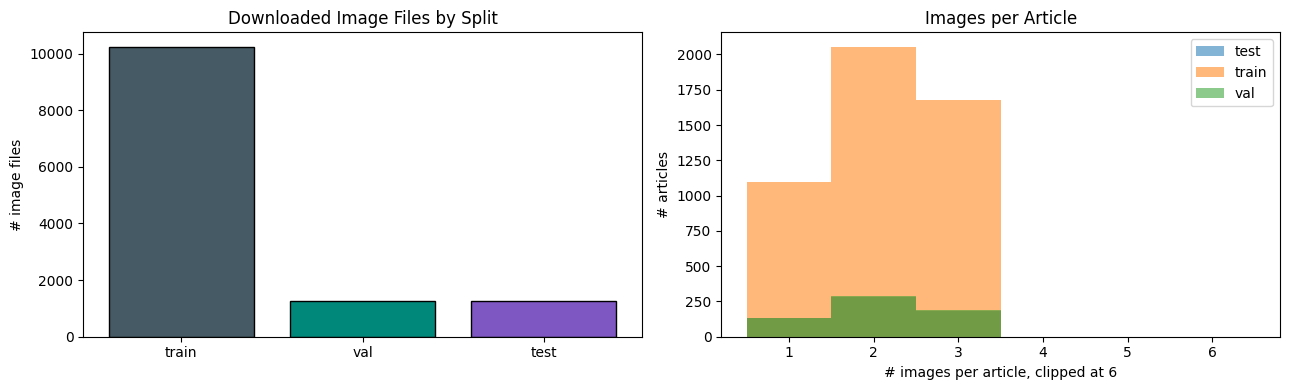

In [18]:
# 7.3 Manifest-based image availability analysis
# Uses your real downloaded images and image_manifests/ files.

def load_image_manifests(manifest_dir: Path) -> pd.DataFrame:
    parts = []
    for split in ['train', 'val', 'test']:
        path = manifest_dir / f'{split}_image_manifest.csv'
        if not path.exists():
            continue
        df = pd.read_csv(path)
        df['split'] = split
        df['image_exists'] = df['image_path'].astype(str).apply(lambda x: Path(x).exists())
        parts.append(df)
    return pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()

image_manifest_df = load_image_manifests(MANIFEST_DIR)
if image_manifest_df.empty:
    print('No image manifests found. Run the image download/preparation notebook first.')
else:
    print(f'Loaded {len(image_manifest_df):,} image manifest rows')
    print(f'Unique articles with >=1 downloaded image: {image_manifest_df["article_id"].nunique():,}')
    print('\nImage files by split:')
    display(image_manifest_df.groupby('split').agg(
        images=('image_path','size'),
        articles=('article_id','nunique'),
        existing_paths=('image_exists','sum')
    ).reset_index())

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    split_counts = image_manifest_df.groupby('split')['image_path'].size().reindex(['train','val','test'])
    axes[0].bar(split_counts.index, split_counts.values, color=['#455A64','#00897B','#7E57C2'], edgecolor='black')
    axes[0].set_title('Downloaded Image Files by Split')
    axes[0].set_ylabel('# image files')

    article_img_counts = image_manifest_df.groupby(['split','article_id']).size().rename('n_images').reset_index()
    for split, grp in article_img_counts.groupby('split'):
        axes[1].hist(grp['n_images'].clip(0, 6), bins=np.arange(1, 8)-0.5, alpha=0.55, label=split)
    axes[1].set_title('Images per Article')
    axes[1].set_xlabel('# images per article, clipped at 6')
    axes[1].set_ylabel('# articles')
    axes[1].legend()
    plt.tight_layout()
    plt.savefig('plot_06_image_manifest_availability.png', dpi=150, bbox_inches='tight')
    plt.show()


Image dimension summary:


width                                                         \
         count    mean     std    min     25%     50%     75%     max   
split                                                                   
test    1246.0  891.51  454.49  100.0  570.75   999.0  1200.0  2000.0   
train  10237.0  914.80  435.24  100.0  636.00   990.0  1200.0  2000.0   
val     1277.0  925.08  462.03  100.0  600.00  1024.0  1200.0  2000.0   

        height          ...                aspect_ratio                    \
         count    mean  ...    75%     max        count  mean   std   min   
split                   ...                                                 
test    1246.0  585.60  ...  720.0  2000.0       1246.0  1.72  0.86  0.31   
train  10237.0  598.13  ...  720.0  2000.0      10237.0  1.72  0.90  0.31   
val     1277.0  597.90  ...  720.0  2000.0       1277.0  1.74  0.98  0.50   

                               
        25%   50%  75%    max  
split                          
test   1.33  1.77  1.9   6.79  
train  1.43  1.66  1.9  28.57  
val    1.33  1.77  1.9  15.87  

[3 rows x 24 columns]


Small-image rate:


split
test     15.49
train    12.97
val      15.66
Name: % below 224px on one side, dtype: float64

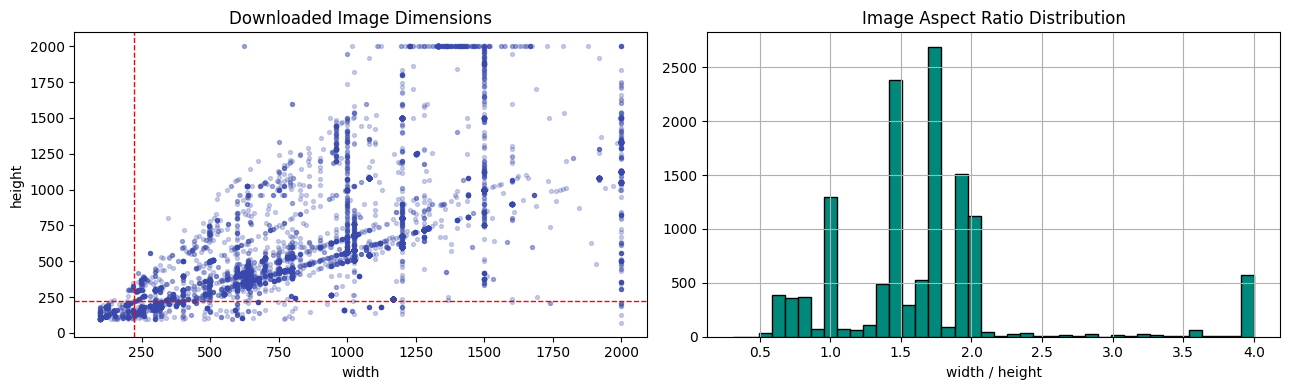


Download status counts:


,split,download_status,count
0,test,HTTPError,72
1,test,ReadTimeout,1
2,test,UnidentifiedImageError,264
3,test,ok,1246
4,test,too_small,332
5,train,ConnectTimeout,3
6,train,ConnectionError,9
7,train,HTTPError,510
8,train,InvalidURL,1
9,train,ReadTimeout,10


In [19]:
# 7.4 Image quality, size, and download-status audit
if 'image_manifest_df' in globals() and not image_manifest_df.empty:
    image_manifest_df['aspect_ratio'] = image_manifest_df['width'] / image_manifest_df['height'].replace(0, np.nan)
    image_manifest_df['small_image'] = (image_manifest_df['width'] < 224) | (image_manifest_df['height'] < 224)

    print('Image dimension summary:')
    display(image_manifest_df.groupby('split')[['width','height','aspect_ratio']].describe().round(2))

    small_summary = image_manifest_df.groupby('split')['small_image'].mean().mul(100).round(2).rename('% below 224px on one side')
    print('\nSmall-image rate:')
    display(small_summary)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].scatter(image_manifest_df['width'], image_manifest_df['height'], s=8, alpha=0.25, color='#3949AB')
    axes[0].axvline(224, color='red', linestyle='--', linewidth=1)
    axes[0].axhline(224, color='red', linestyle='--', linewidth=1)
    axes[0].set_title('Downloaded Image Dimensions')
    axes[0].set_xlabel('width'); axes[0].set_ylabel('height')

    image_manifest_df['aspect_ratio'].clip(0, 4).hist(ax=axes[1], bins=40, color='#00897B', edgecolor='black')
    axes[1].set_title('Image Aspect Ratio Distribution')
    axes[1].set_xlabel('width / height')
    plt.tight_layout()
    plt.savefig('plot_07_image_dimensions.png', dpi=150, bbox_inches='tight')
    plt.show()

    download_parts = []
    for split in ['train','val','test']:
        path = MANIFEST_DIR / f'{split}_download_manifest.csv'
        if path.exists():
            tmp = pd.read_csv(path)
            tmp['split'] = split
            download_parts.append(tmp)
    download_manifest_df = pd.concat(download_parts, ignore_index=True) if download_parts else pd.DataFrame()
    if not download_manifest_df.empty:
        status_counts = download_manifest_df.groupby(['split','download_status']).size().reset_index(name='count')
        status_counts.to_csv(FINAL_ARTIFACT_DIR/'eda_image_download_status_counts.csv', index=False)
        print('\nDownload status counts:')
        display(status_counts)
else:
    print('No image_manifest_df available - skipping image quality audit.')


Primary-image coverage by split:


,split,rows,fake,real,valid_primary_images,image_coverage_%
0,test,1005,477,528,540,53.73
1,train,8843,4345,4498,4829,54.61
2,val,1016,477,539,566,55.71



Primary-image coverage by split/source/label:


,split,source,label,rows,valid_primary_images,image_coverage_%
0,test,gossipcop,fake,435,242,55.63
1,test,gossipcop,real,477,288,60.38
2,test,politifact,fake,42,6,14.29
3,test,politifact,real,51,4,7.84
4,train,gossipcop,fake,3999,2242,56.06
5,train,gossipcop,real,4000,2462,61.55
6,train,politifact,fake,346,78,22.54
7,train,politifact,real,498,47,9.44
8,val,gossipcop,fake,434,253,58.29
9,val,gossipcop,real,487,297,60.99


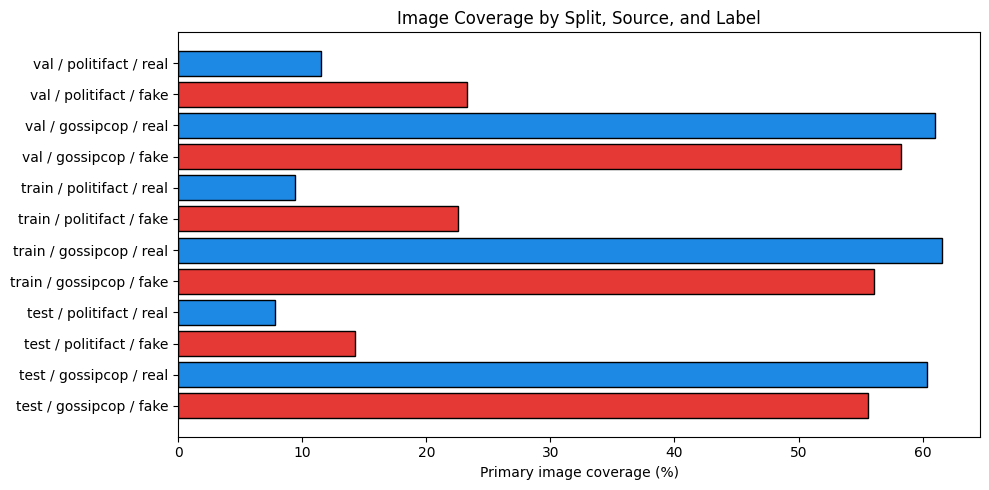

In [20]:
# 7.5 Multimodal coverage by split, source, and label
# This is the key image/text EDA table for the report.

def load_multimodal_splits(split_dir: Path) -> pd.DataFrame:
    parts = []
    for split in ['train', 'val', 'test']:
        path = split_dir / f'{split}_multimodal.csv'
        if not path.exists():
            continue
        df = pd.read_csv(path)
        df['split'] = split
        if 'image_path_primary' in df.columns:
            df['valid_image_path'] = df['image_path_primary'].apply(lambda x: isinstance(x, str) and Path(x).exists())
        else:
            df['valid_image_path'] = False
        parts.append(df)
    return pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()

multimodal_df = load_multimodal_splits(DATA_SPLIT_DIR)
if multimodal_df.empty:
    print('No multimodal split CSVs found. Run the image preparation notebook first.')
else:
    coverage_split = multimodal_df.groupby('split').agg(
        rows=('id','size'),
        fake=('label', lambda s: int((s == 'fake').sum())),
        real=('label', lambda s: int((s == 'real').sum())),
        valid_primary_images=('valid_image_path','sum')
    ).reset_index()
    coverage_split['image_coverage_%'] = (100 * coverage_split['valid_primary_images'] / coverage_split['rows']).round(2)

    coverage_source_label = multimodal_df.groupby(['split','source','label']).agg(
        rows=('id','size'),
        valid_primary_images=('valid_image_path','sum')
    ).reset_index()
    coverage_source_label['image_coverage_%'] = (100 * coverage_source_label['valid_primary_images'] / coverage_source_label['rows']).round(2)

    coverage_split.to_csv(FINAL_ARTIFACT_DIR/'eda_image_coverage_by_split.csv', index=False)
    coverage_source_label.to_csv(FINAL_ARTIFACT_DIR/'eda_image_coverage_by_split_source_label.csv', index=False)

    print('Primary-image coverage by split:')
    display(coverage_split)
    print('\nPrimary-image coverage by split/source/label:')
    display(coverage_source_label)

    fig, ax = plt.subplots(figsize=(10, 5))
    plot_df = coverage_source_label.copy()
    plot_df['group'] = plot_df['split'] + ' / ' + plot_df['source'] + ' / ' + plot_df['label']
    colors = plot_df['label'].map(PALETTE)
    ax.barh(plot_df['group'], plot_df['image_coverage_%'], color=colors, edgecolor='black')
    ax.set_xlabel('Primary image coverage (%)')
    ax.set_title('Image Coverage by Split, Source, and Label')
    plt.tight_layout()
    plt.savefig('plot_08_image_coverage_source_label.png', dpi=150, bbox_inches='tight')
    plt.show()


## 8 · Tweet-ID Column Exploration

In [21]:
# tweet_ids column is tab-separated inside the CSV string
def count_tweets(val):
    if pd.isnull(val):
        return 0
    return len(str(val).split('\t'))

raw['n_tweet_ids'] = raw['tweet_ids'].apply(count_tweets)

print('Tweet-ID count statistics by label:')
print(raw.groupby('label')['n_tweet_ids'].describe().round(1))

print('\nArticles with NO tweet IDs by label:')
print(raw[raw['n_tweet_ids']==0].groupby('label').size())

Tweet-ID count statistics by label:
         count   mean    std  min   25%   50%   75%      max
label                                                       
fake    5755.0  132.7  548.2  0.0   5.0  13.0  51.0  29060.0
real   17441.0   74.5  466.5  0.0  17.0  44.0  66.0  27377.0

Articles with NO tweet IDs by label:
label
fake     228
real    1273
dtype: int64


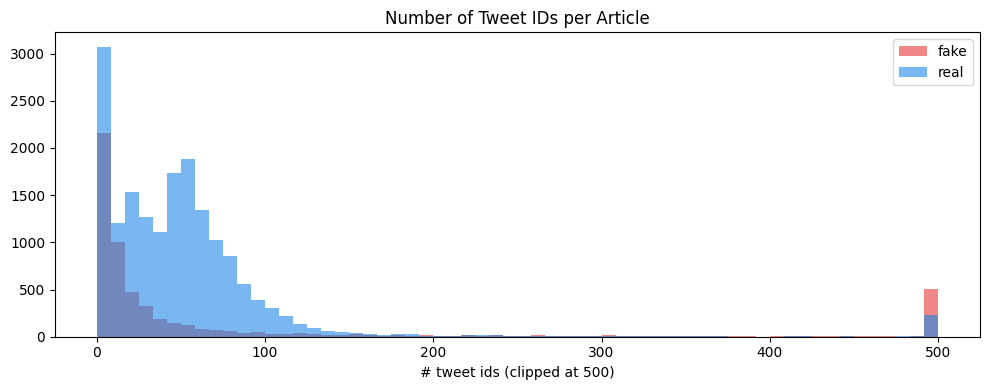

In [22]:
fig, ax = plt.subplots(figsize=(10, 4))
for label, grp in raw.groupby('label'):
    ax.hist(grp['n_tweet_ids'].clip(0, 500), bins=60,
            alpha=0.6, label=label, color=PALETTE[label])
ax.set_title('Number of Tweet IDs per Article', fontsize=12)
ax.set_xlabel('# tweet ids (clipped at 500)'); ax.legend()
plt.tight_layout()
plt.savefig('plot_08_tweet_ids.png', dpi=150, bbox_inches='tight')
plt.show()

## 9 · Data Cleaning & Deduplication

In [23]:
# ── 9.1 Exact duplicate IDs ───────────────────────────────────────────────────
print('Duplicate article IDs (same id, same source):')
dups = raw[raw.duplicated(subset=['id', 'source'], keep=False)]
print(f'  {len(dups):,} rows involved in {dups.groupby(["id","source"]).ngroups:,} duplicate groups')

# Inspect any duplicates that disagree on label (critical data quality issue)
label_conflict = (raw.groupby(['id','source'])['label']
                    .nunique()
                    .reset_index(name='n_labels')
                    .query('n_labels > 1'))
print(f'\nLabel-conflicting duplicates: {len(label_conflict)}')
if len(label_conflict):
    print(label_conflict.head(10))

Duplicate article IDs (same id, same source):
  4 rows involved in 2 duplicate groups

Label-conflicting duplicates: 2
                    id      source  n_labels
22597  politifact14920  politifact         2
22600  politifact14940  politifact         2


In [24]:
# ── 9.2 Duplicate titles ──────────────────────────────────────────────────────
dup_titles = raw[raw.duplicated(subset=['title'], keep=False) & raw['title'].notna()]
print(f'Rows with duplicate titles: {len(dup_titles):,}')
# Show a sample of cross-label title duplicates
cross = (dup_titles.groupby('title')['label'].nunique() > 1)
cross_titles = cross[cross].index.tolist()
print(f'Titles that appear as BOTH fake and real: {len(cross_titles)}')
if cross_titles:
    print(dup_titles[dup_titles['title'].isin(cross_titles[:3])]
          [['id','source','label','title']])

Rows with duplicate titles: 2,435
Titles that appear as BOTH fake and real: 123
                         id     source label  \
1585    gossipcop-658317851  gossipcop  fake   
4904   gossipcop-6345913771  gossipcop  fake   
5688   gossipcop-1760401680  gossipcop  fake   
15329      gossipcop-907816  gossipcop  real   
21656      gossipcop-871199  gossipcop  real   
21914      gossipcop-866572  gossipcop  real   

                                                                                         title  
1585                                2017 Emmy Nominees List: See All the Nominations – Variety  
4904   'The Bachelorette' Finale: Engaged Rachel Lindsay Reveals Her Winner in Historic Season  
5688                           2018 SAG Award Nominations: See Full List of Nominees – Variety  
15329                          2018 SAG Award Nominations: See Full List of Nominees – Variety  
21656  'The Bachelorette' Finale: Engaged Rachel Lindsay Reveals Her Winner in Historic Season  
2

In [25]:
# ── 9.3 Clean: remove duplicates, drop missing titles, strip whitespace ────────
clean = raw.copy()

# Strip leading/trailing whitespace from text columns
for col in ['title', 'news_url']:
    if col in clean.columns:
        clean[col] = clean[col].str.strip()

# Drop rows where title is null or empty (can't classify without any text signal)
before = len(clean)
clean = clean[clean['title'].notna() & clean['title'].ne('')]
print(f'Dropped {before - len(clean)} rows with null/empty title')

# Keep first occurrence of each (id, source) pair
before = len(clean)
clean = clean.drop_duplicates(subset=['id', 'source'], keep='first')
print(f'Dropped {before - len(clean)} duplicate (id, source) rows')

print(f'\nClean dataset shape: {clean.shape}')
print(clean.groupby(['source','label']).size().unstack())

Dropped 0 rows with null/empty title
Dropped 2 duplicate (id, source) rows

Clean dataset shape: (23194, 19)
label       fake   real
source                 
gossipcop   5323  16817
politifact   432    622


In [26]:
# ── 9.4 If full content available: merge & flag usable rows ───────────────────
if FULL_DATA_AVAILABLE and not content_df.empty:
    clean = clean.merge(
        content_df[['id','source','text','images','publish_date',
                    'top_img','has_image','n_images','text_missing']],
        on=['id','source'], how='left'
    )

    # Flag rows usable for multimodal training
    clean['usable_text']  = ~clean['text_missing'].fillna(True)
    clean['usable_image'] = clean['has_image'].fillna(False)
    clean['usable_both']  = clean['usable_text'] & clean['usable_image']

    print('Usability flags:')
    print(clean[['usable_text','usable_image','usable_both']]
          .mean().mul(100).round(1).rename('% usable'))

    print('\nUsable for BOTH modalities by (source, label):')
    print(clean[clean['usable_both']].groupby(['source','label']).size().unstack())
else:
    print('Full content not available — usability flags skipped.')
    # Add placeholder flags based on what we do have
    clean['usable_text']  = clean['title'].notna()
    clean['usable_image'] = False
    clean['usable_both']  = False

Full content not available — usability flags skipped.


## 10 · Balanced Subset Construction

In [27]:
# 10.1 Strategy: build a modelling pool without title leakage
# We balance fake / real within each source and remove duplicate normalized titles
# before splitting, so the same headline cannot appear in train/val/test.

SEED = 42
N_PER_CLASS = 5000

import re

def normalize_title_for_split(value):
    if not isinstance(value, str):
        return ''
    value = value.lower()
    value = re.sub(r'[^a-z0-9]+', ' ', value)
    return re.sub(r'\s+', ' ', value).strip()

if FULL_DATA_AVAILABLE and not content_df.empty:
    pool = clean[clean['usable_both']].copy()
    print(f'Multimodal pool: {len(pool):,} articles (text + image both available)')
else:
    pool = clean.copy()
    print(f'Title-only pool: {len(pool):,} articles (working with CSV metadata only)')

pool['title_norm_split'] = pool['title'].apply(normalize_title_for_split)
blank_titles = int((pool['title_norm_split'] == '').sum())
if blank_titles:
    print(f'Removing {blank_titles:,} rows with blank normalized titles before splitting')
    pool = pool[pool['title_norm_split'] != ''].copy()

before_dedupe = len(pool)
pool = pool.sort_values(['source', 'label', 'id']).drop_duplicates(subset=['title_norm_split'], keep='first').copy()
print(f'Removed {before_dedupe - len(pool):,} duplicate normalized-title rows before splitting')

print('\nAvailable samples per (source, label) after title de-duplication:')
print(pool.groupby(['source','label']).size().unstack())


Title-only pool: 23,194 articles (working with CSV metadata only)
Removing 3 rows with blank normalized titles before splitting
Removed 1,481 duplicate normalized-title rows before splitting

Available samples per (source, label) after title de-duplication:
label       fake   real
source                 
gossipcop   4894  15838
politifact   425    553


In [28]:
# 10.2 Sample balanced subsets and split with leakage guards
from sklearn.model_selection import train_test_split

def balanced_sample(df, n_per_group, seed=42):
    """Sample up to n_per_group rows from each (source, label) group."""
    parts = []
    for (src, lbl), grp in df.groupby(['source', 'label']):
        n = min(n_per_group, len(grp))
        parts.append(grp.sample(n, random_state=seed))
        print(f'  {src}/{lbl}: sampled {n:,} (available {len(grp):,})')
    return pd.concat(parts, ignore_index=True)

subset = balanced_sample(pool, N_PER_CLASS, seed=SEED)
subset = subset.sample(frac=1, random_state=SEED).reset_index(drop=True)

strata = subset['source'].astype(str) + '__' + subset['label'].astype(str)
train_val, test = train_test_split(subset, test_size=0.10, stratify=strata, random_state=SEED)
train_val_strata = train_val['source'].astype(str) + '__' + train_val['label'].astype(str)
train, val = train_test_split(train_val, test_size=0.111, stratify=train_val_strata, random_state=SEED)

for a_name, a_df, b_name, b_df in [('train', train, 'val', val), ('train', train, 'test', test), ('val', val, 'test', test)]:
    overlap = (set(a_df['title_norm_split']) - {''}) & (set(b_df['title_norm_split']) - {''})
    if overlap:
        raise ValueError(f'Title leakage detected between {a_name} and {b_name}: {len(overlap)} normalized titles')

print(f'\nSplit sizes - train: {len(train):,}  val: {len(val):,}  test: {len(test):,}')
print('\nTrain label distribution:')
print(train.groupby(['source', 'label']).size().unstack(fill_value=0))
print('\nValidation label distribution:')
print(val.groupby(['source', 'label']).size().unstack(fill_value=0))
print('\nTest label distribution:')
print(test.groupby(['source', 'label']).size().unstack(fill_value=0))


  gossipcop/fake: sampled 4,894 (available 4,894)
  gossipcop/real: sampled 5,000 (available 15,838)
  politifact/fake: sampled 425 (available 425)
  politifact/real: sampled 553 (available 553)

Split sizes - train: 8,697  val: 1,087  test: 1,088

Train label distribution:
label       fake  real
source                
gossipcop   3915  4000
politifact   339   443

Validation label distribution:
label       fake  real
source                
gossipcop    489   500
politifact    43    55

Test label distribution:
label       fake  real
source                
gossipcop    490   500
politifact    43    55


In [29]:
# ── 10.3 Save splits ──────────────────────────────────────────────────────────
os.makedirs('data_splits', exist_ok=True)

train.to_csv('data_splits/train.csv', index=False)
val.to_csv(  'data_splits/val.csv',   index=False)
test.to_csv( 'data_splits/test.csv',  index=False)

# Also save the full clean dataframe for reference
clean.to_csv('data_splits/clean_full.csv', index=False)

print('Saved:')
print('  data_splits/train.csv       —', len(train), 'rows')
print('  data_splits/val.csv         —', len(val),   'rows')
print('  data_splits/test.csv        —', len(test),  'rows')
print('  data_splits/clean_full.csv  —', len(clean), 'rows')

Saved:
  data_splits/train.csv       — 8697 rows
  data_splits/val.csv         — 1087 rows
  data_splits/test.csv        — 1088 rows
  data_splits/clean_full.csv  — 23194 rows


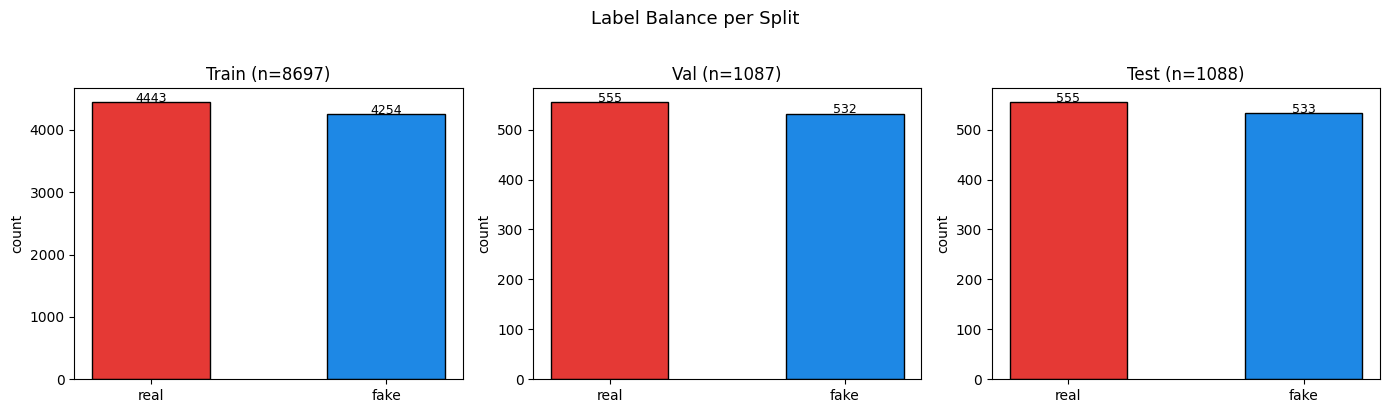

In [30]:
# ── 10.4 Final split visualisation ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (split_name, split_df) in zip(axes, [('Train', train), ('Val', val), ('Test', test)]):
    counts = split_df['label'].value_counts()
    ax.bar(counts.index, counts.values,
           color=[FAKE_CLR, REAL_CLR], edgecolor='black', width=0.5)
    ax.set_title(f'{split_name} (n={len(split_df)})', fontsize=12)
    ax.set_ylabel('count')
    for bar, v in zip(ax.patches, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 1, str(v), ha='center', fontsize=9)

plt.suptitle('Label Balance per Split', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('plot_09_split_balance.png', dpi=150, bbox_inches='tight')
plt.show()


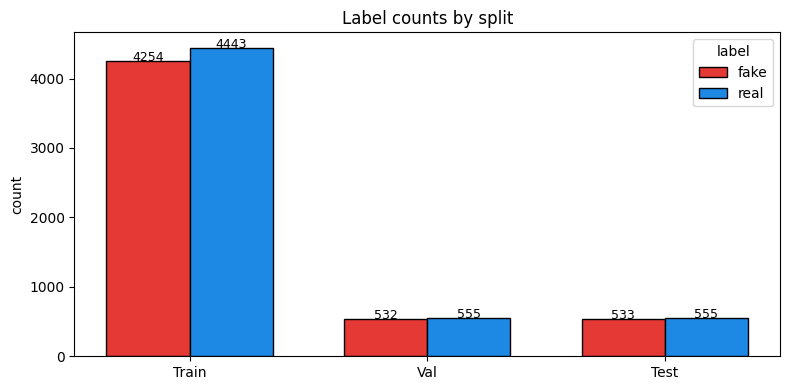

In [31]:
# Combined split comparison: train / val / test in one graph
split_summary = []
for split_name, split_df in [('Train', train), ('Val', val), ('Test', test)]:
    counts = split_df['label'].value_counts()
    split_summary.append({
        'split': split_name,
        'fake': counts.get('fake', 0),
        'real': counts.get('real', 0),
    })
split_summary = pd.DataFrame(split_summary)

fig2, ax2 = plt.subplots(figsize=(8, 4))
x = np.arange(len(split_summary))
width = 0.35
ax2.bar(x - width/2, split_summary['fake'], width,
        label='fake', color=FAKE_CLR, edgecolor='black')
ax2.bar(x + width/2, split_summary['real'], width,
        label='real', color=REAL_CLR, edgecolor='black')
ax2.set_xticks(x)
ax2.set_xticklabels(split_summary['split'])
ax2.set_ylabel('count')
ax2.set_title('Label counts by split', fontsize=12)
ax2.legend(title='label')
for i, (fake_count, real_count) in enumerate(zip(split_summary['fake'], split_summary['real'])):
    ax2.text(x[i] - width/2, fake_count + 1, str(fake_count), ha='center', fontsize=9)
    ax2.text(x[i] + width/2, real_count + 1, str(real_count), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('plot_09_split_balance_combined.png', dpi=150, bbox_inches='tight')
plt.show()

## 11 · Summary & Next-Step Checklist

Run this cell after completing all sections above. It prints a structured checklist
of findings and recommended next steps for feature engineering and modelling.

In [32]:
divider = '=' * 65

print(divider)
print('EXPLORATION SUMMARY')
print(divider)

print(f'\n[DATA SIZES]')
print(f'  Raw rows loaded          : {len(raw):,}')
print(f'  After cleaning           : {len(clean):,}')
print(f'  Balanced subset (all)    : {len(subset):,}')
print(f'  Train / Val / Test       : {len(train):,} / {len(val):,} / {len(test):,}')

print(f'\n[CLASS BALANCE]')
for lbl, cnt in clean['label'].value_counts().items():
    print(f'  {lbl:6s}: {cnt:,}')

print(f'\n[MISSING VALUES — clean set]')
for col, cnt in clean.isnull().sum().items():
    if cnt > 0:
        print(f'  {col:30s}: {cnt:,} ({cnt/len(clean)*100:.1f}%)')

if FULL_DATA_AVAILABLE and 'usable_both' in clean.columns:
    print(f'\n[MULTIMODAL READINESS]')
    print(f'  Has text body            : {clean["usable_text"].sum():,} '
          f'({clean["usable_text"].mean()*100:.1f}%)')
    print(f'  Has at least 1 image URL : {clean["usable_image"].sum():,} '
          f'({clean["usable_image"].mean()*100:.1f}%)')
    print(f'  Both text + image        : {clean["usable_both"].sum():,} '
          f'({clean["usable_both"].mean()*100:.1f}%)')

print(f'\n{divider}')
print('RECOMMENDED NEXT STEPS')
print(divider)
checklist = [
    'TEXT: Confirm DistilBERT token-length coverage (target: < 5% truncated at 512 tok)',
    'TEXT: Check if body text or title is more discriminative — run TF-IDF LogReg on each',
    'TEXT: Consider concatenating title + first 200 words of body as unified text input',
    'IMAGE: Verify image URLs are reachable (HTTP 200) — report % broken links',
    'IMAGE: Check image resolution distribution — resize strategy for ResNet-18 (224x224)',
    'IMAGE: Flag images that are logos/icons (< 10KB) vs. editorial photos (> 50KB)',
    'BALANCE: Confirm train/val/test label counts are equal fake/real after splitting',
    'FEATURE ENG: title_exclaim_count, title_punct_density as auxiliary features?',
    'FEATURE ENG: n_tweet_ids (social engagement proxy) — consider as side feature',
    'FEATURE ENG: domain as categorical feature (encode top-50 domains)',
    'FEATURE ENG: publish_year as temporal feature if date coverage spans multiple years',
    'MODELLING: Decide whether to use title-only or title+body for text encoder input',
]
for i, item in enumerate(checklist, 1):
    print(f'  [{i:02d}] {item}')

print(f'\n{divider}')
print('SAVED FILES')
print(divider)
for fn in sorted(Path('.').glob('plot_*.png')):
    print(f'  {fn}')
for fn in sorted(Path('data_splits').glob('*.csv')):
    print(f'  {fn}')


EXPLORATION SUMMARY

[DATA SIZES]
  Raw rows loaded          : 23,196
  After cleaning           : 23,194
  Balanced subset (all)    : 10,872
  Train / Val / Test       : 8,697 / 1,087 / 1,088

[CLASS BALANCE]
  real  : 17,439
  fake  : 5,755

[MISSING VALUES — clean set]
  news_url                      : 330 (1.4%)
  tweet_ids                     : 1,501 (6.5%)

RECOMMENDED NEXT STEPS
  [01] TEXT: Confirm DistilBERT token-length coverage (target: < 5% truncated at 512 tok)
  [02] TEXT: Check if body text or title is more discriminative — run TF-IDF LogReg on each
  [03] TEXT: Consider concatenating title + first 200 words of body as unified text input
  [04] IMAGE: Verify image URLs are reachable (HTTP 200) — report % broken links
  [05] IMAGE: Check image resolution distribution — resize strategy for ResNet-18 (224x224)
  [06] IMAGE: Flag images that are logos/icons (< 10KB) vs. editorial photos (> 50KB)
  [07] BALANCE: Confirm train/val/test label counts are equal fake/real after sp

## 12 · Report-Ready MS1 Findings

These are the points to transfer directly into the midterm report:

1. **Dataset imbalance:** the original FakeNewsNet subset is imbalanced toward real news, so the initial experiments use a balanced subset to avoid majority-class bias.
2. **Source bias:** most samples come from GossipCop, while PolitiFact is much smaller. This motivates stratifying the split by both `source` and `label`.
3. **Domain bias:** fake and real samples have different dominant domains, so the final model should not rely only on `news_url` or domain features.
4. **Text signal:** fake and real title-length distributions overlap heavily, suggesting that simple title-length features are not enough.
5. **Tweet metadata:** tweet IDs are missing or highly skewed for many articles; therefore, tweet metadata is treated as optional and is not required by the main MS1 model.
6. **Initial split:** the notebook creates balanced train/validation/test CSV files used by the image preparation and multimodal training notebooks.


---
# FINAL-UPGRADE ADDENDUM: Leakage, Image Coverage, and Bias Audits

This section addresses the high-impact review items for the final submission: duplicate/title leakage, source/domain shortcut risk, image coverage consistency, and valid-image-only statistics. Run it after the original EDA cells.

In [33]:
# FINAL UPGRADE 01-A: Robust split and manifest loading helpers
from pathlib import Path
import pandas as pd
import numpy as np
import re, json, os

DATA_SPLIT_DIR = Path('data_splits')
MANIFEST_DIR = Path('image_manifests')
FINAL_ARTIFACT_DIR = Path('final_artifacts')
FINAL_ARTIFACT_DIR.mkdir(exist_ok=True)

def _read_csv_if_exists(path: Path):
    return pd.read_csv(path) if path.exists() else None

def load_any_split(split: str) -> pd.DataFrame:
    """Prefer multimodal split, otherwise fallback to plain split created by Notebook 01."""
    for name in [f'{split}_multimodal.csv', f'{split}.csv']:
        path = DATA_SPLIT_DIR / name
        if path.exists():
            df = pd.read_csv(path)
            df['split'] = split
            return df
    raise FileNotFoundError(f'Missing {split} split in {DATA_SPLIT_DIR.resolve()}')

def normalize_title_for_grouping(title):
    if not isinstance(title, str):
        return ''
    title = title.lower().strip()
    title = re.sub(r'https?://\S+|www\.\S+', ' ', title)
    title = re.sub(r'[^a-z0-9]+', ' ', title)
    return re.sub(r'\s+', ' ', title).strip()

splits_available = {}
for split in ['train', 'val', 'test']:
    try:
        splits_available[split] = load_any_split(split)
        print(f'Loaded {split}: {splits_available[split].shape}')
    except FileNotFoundError as e:
        print('WARNING:', e)

if splits_available:
    all_splits_df = pd.concat(splits_available.values(), ignore_index=True)
    all_splits_df['title_norm'] = all_splits_df['title'].apply(normalize_title_for_grouping)
    display(all_splits_df.head(2))
else:
    print('No split files found. Run the original split-creation cells first.')

Loaded train: (8843, 27)
Loaded val: (1016, 27)
Loaded test: (1005, 27)


,id,news_url,title,tweet_ids,source,label,title_len_chars,title_len_words,title_has_null,title_is_empty,...,n_tweet_ids,usable_text,usable_image,usable_both,has_image,image_path_primary,image_paths,n_images_downloaded,split,title_norm
0,gossipcop-9544512911,hollywoodlife.com/2018/03/14/are-ben-affleck-jennifer-garner-getting-back-together-split-breakup/,Ben Affleck Reportedly Begging Jennifer Garner For Second Shot At Love: Will She Go Back To Him?,973967302961123328\t973967309642625026\t973969646444531713\t973971161716547584\t973974575737286656\t9739778798758584...,gossipcop,fake,96,17,False,False,...,13,True,False,False,False,NaN,NaN,0,train,ben affleck reportedly begging jennifer garner for second shot at love will she go back to him
1,gossipcop-4313375432,www.townandcountrymag.com/society/tradition/a19674665/kate-middleton-post-birth-appearance-differences-comparison/,How Kate Middleton’s First Appearance With Royal Baby No. 3 Compares to George and Charlotte’s Debuts,988468708728328194\t988478659311874049\t988489811672621056\t988489830274338816\t988510440593547264\t9885148393529139...,gossipcop,fake,101,16,False,False,...,12,True,True,True,True,images\train\gossipcop-4313375432_0_4a9d412e5e.jpg,images\train\gossipcop-4313375432_0_4a9d412e5e.jpg;images\train\gossipcop-4313375432_1_1441f6c866.jpg,2,train,how kate middleton s first appearance with royal baby no 3 compares to george and charlotte s debuts


In [34]:
# FINAL UPGRADE 01-B: Train/validation/test leakage audit
if splits_available:
    rows = []
    for a, b in [('train', 'val'), ('train', 'test'), ('val', 'test')]:
        A = set(all_splits_df.loc[all_splits_df['split'] == a, 'title_norm']) - {''}
        B = set(all_splits_df.loc[all_splits_df['split'] == b, 'title_norm']) - {''}
        overlap = A & B
        rows.append({'pair': f'{a}-{b}', 'duplicate_normalized_titles': len(overlap),
                     'overlap_%_of_smaller_split': round(100*len(overlap)/max(1, min(len(A), len(B))), 3)})
    leakage_audit = pd.DataFrame(rows)
    leakage_audit.to_csv(FINAL_ARTIFACT_DIR/'final_title_leakage_audit.csv', index=False)
    display(leakage_audit)

    # Cross-label duplicate titles inside the complete modelling data.
    label_mix = (all_splits_df.groupby('title_norm')['label']
                 .nunique().reset_index(name='n_unique_labels'))
    ambiguous_titles = label_mix[label_mix['n_unique_labels'] > 1]
    print(f'Cross-label duplicate normalized titles: {len(ambiguous_titles)}')
    if len(ambiguous_titles):
        examples = all_splits_df[all_splits_df['title_norm'].isin(ambiguous_titles['title_norm'])]
        examples[['split','id','source','label','title']].head(20).to_csv(FINAL_ARTIFACT_DIR/'final_cross_label_duplicate_title_examples.csv', index=False)
        display(examples[['split','id','source','label','title']].head(10))

,pair,duplicate_normalized_titles,overlap_%_of_smaller_split
0,train-val,0,0.0
1,train-test,0,0.0
2,val-test,0,0.0


Cross-label duplicate normalized titles: 27


,split,id,source,label,title
84,train,gossipcop-867227,gossipcop,real,Caitlyn Jenner latest celebrity to float run for office
122,train,gossipcop-2345398796,gossipcop,fake,"Meghan, Duchess of Sussex"
537,train,gossipcop-6695779931,gossipcop,fake,JAY-Z Reveals Why He and Beyoncé Chose the Names Rumi and Sir for Their Twins
630,train,gossipcop-9040197271,gossipcop,fake,Jennifer Aniston
927,train,gossipcop-882692,gossipcop,real,Sofia Richie
1059,train,gossipcop-910301,gossipcop,real,ABC News Radio
1120,train,gossipcop-930287,gossipcop,real,"Royal Baby's Name Is Louis Arthur Charles, Will and Kate Announce"
1428,train,gossipcop-899906,gossipcop,real,Opinion | Harvey Weinstein Is My Monster Too
1777,train,gossipcop-843465,gossipcop,real,George Clooney
1878,train,politifact5276,politifact,real,子供たちのコト。私のコト。


In [35]:
# FINAL UPGRADE 01-C: Image coverage audit by split, label, and source
# This is the table that should go into the final report.
def valid_path_flag(row):
    for col in ['valid_image_path', 'image_exists']:
        if col in row.index:
            val = row[col]
            if isinstance(val, (bool, np.bool_)):
                return bool(val)
            if isinstance(val, str):
                return val.strip().lower() in {'true','1','yes'}
    for col in ['image_path_primary', 'image_path', 'local_image_path']:
        if col in row.index and isinstance(row[col], str) and row[col].strip():
            return Path(row[col]).exists()
    return False

if splits_available:
    tmp = all_splits_df.copy()
    tmp['valid_image_path_final'] = tmp.apply(valid_path_flag, axis=1)
    image_coverage_split = (tmp.groupby('split')
        .agg(n_rows=('id','size'), fake=('label', lambda s: (s=='fake').sum()), real=('label', lambda s: (s=='real').sum()),
             valid_images=('valid_image_path_final','sum'))
        .reset_index())
    image_coverage_split['image_coverage_%'] = (100*image_coverage_split['valid_images']/image_coverage_split['n_rows']).round(2)
    image_coverage_label_source = (tmp.groupby(['split','source','label'])
        .agg(n_rows=('id','size'), valid_images=('valid_image_path_final','sum')).reset_index())
    image_coverage_label_source['image_coverage_%'] = (100*image_coverage_label_source['valid_images']/image_coverage_label_source['n_rows']).round(2)

    image_coverage_split.to_csv(FINAL_ARTIFACT_DIR/'final_image_coverage_by_split.csv', index=False)
    image_coverage_label_source.to_csv(FINAL_ARTIFACT_DIR/'final_image_coverage_by_split_source_label.csv', index=False)
    print('Image coverage by split:')
    display(image_coverage_split)
    print('Image coverage by split/source/label:')
    display(image_coverage_label_source)

    # Save valid-image-only IDs for Notebook 03.
    tmp[tmp['valid_image_path_final']].to_csv(FINAL_ARTIFACT_DIR/'final_valid_image_only_all_splits.csv', index=False)
else:
    print('No splits loaded.')

Image coverage by split:


,split,n_rows,fake,real,valid_images,image_coverage_%
0,test,1005,477,528,540,53.73
1,train,8843,4345,4498,4829,54.61
2,val,1016,477,539,566,55.71


Image coverage by split/source/label:


,split,source,label,n_rows,valid_images,image_coverage_%
0,test,gossipcop,fake,435,242,55.63
1,test,gossipcop,real,477,288,60.38
2,test,politifact,fake,42,6,14.29
3,test,politifact,real,51,4,7.84
4,train,gossipcop,fake,3999,2242,56.06
5,train,gossipcop,real,4000,2462,61.55
6,train,politifact,fake,346,78,22.54
7,train,politifact,real,498,47,9.44
8,val,gossipcop,fake,434,253,58.29
9,val,gossipcop,real,487,297,60.99


In [36]:
# FINAL UPGRADE 01-D: Source/domain shortcut audit
# Purpose: prove to the grader that source/domain variables are audited, not used as model inputs.
if 'raw' in globals():
    audit_source_label = raw.groupby(['source','label']).size().unstack(fill_value=0)
    audit_source_label['fake_rate'] = audit_source_label.get('fake',0) / audit_source_label.sum(axis=1)
    audit_source_label.to_csv(FINAL_ARTIFACT_DIR/'final_source_label_shortcut_audit.csv')
    display(audit_source_label)

    if 'domain' in raw.columns:
        domain_bias = raw.groupby('domain')['label'].agg(n='size', fake_rate=lambda x: (x=='fake').mean()).reset_index()
        domain_bias = domain_bias[domain_bias['n'] >= 20].sort_values(['fake_rate','n'], ascending=[False,False])
        domain_bias.to_csv(FINAL_ARTIFACT_DIR/'final_domain_shortcut_audit_min20.csv', index=False)
        print('High-frequency domains with strongest label skew:')
        display(domain_bias.head(20))
else:
    print('Run original EDA cells first so raw/domain variables exist.')

label,fake,real,fake_rate
source,,,
gossipcop,5323,16817,0.240425
politifact,432,624,0.409091


High-frequency domains with strongest label skew:


,domain,n,fake_rate
618,eonline.com,154,1.000000
949,imdb.com,145,1.000000
1328,nationalenquirer.com,53,1.000000
2409,yournewswire.com,25,1.000000
328,celebdirtylaundry.com,21,1.000000
330,celebitchy.com,21,1.000000
1631,pressreader.com,20,1.000000
936,ibtimes.co.in,28,0.964286
1367,newidea.com.au,143,0.958042
1574,pinterest.co.uk,22,0.909091
